In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

!ls "/content/drive/MyDrive/Deepfake_Audio_Project"

'EnvSDD-Development (Unzipped Files)'  'final-project-pied-piper-main 2'
 EnvSDD-Development.zip		        LA.zip
 EnvSDD_extracted		       'LENS-DF Sample Data (Unzipped Files)'
 EnvSDD-Test			       'LENS-DF Sample Data.zip'
 EnvSDD-Test.zip


In [ ]:
# Copy the unzipped folder to local Colab memory
!cp -r "/content/drive/MyDrive/Deepfake_Audio_Project/LENS-DF Sample Data (Unzipped Files)" "/content/lens_data"

In [ ]:
import os
wav_files = os.listdir("/content/lens_data/dev/wavs")
print(f"Total wav files: {len(wav_files)}")

Total wav files: 2000


In [ ]:
import os

local_path = "/content/lens_data/dev/wavs"
# This will list the first 5 files to confirm it's working
print(os.listdir(local_path)[:5])

# Count total wav files
wav_files = [f for f in os.listdir(local_path) if f.endswith('.wav')]
print(f"Total .wav files found: {len(wav_files)}")

['LA_spoof_3_7_255.wav', 'LA_bonafide_10_450.wav', 'LA_bonafide_10_432.wav', 'LA_bonafide_10_962.wav', 'LA_bonafide_10_161.wav']
Total .wav files found: 2000


In [ ]:
import os

local_path = "/content/lens_data/dev/wavs"
wav_files = os.listdir(local_path)

print(f"The names of files: {wav_files}")

real = [f for f in wav_files if "bonafide" in f]
fake = [f for f in wav_files if "spoof" in f]

print(f"Total files : {len(wav_files)}")
print(f"Real (bonafide): {len(real)}")
print(f"Fake (spoof)   : {len(fake)}")
print(f"Ratio fake/real: {len(fake)/len(real):.2f}")

The names of files: ['LA_spoof_3_7_255.wav', 'LA_bonafide_10_450.wav', 'LA_bonafide_10_432.wav', 'LA_bonafide_10_962.wav', 'LA_bonafide_10_161.wav', 'LA_spoof_3_7_409.wav', 'LA_spoof_3_7_587.wav', 'LA_bonafide_10_380.wav', 'LA_bonafide_10_12.wav', 'LA_bonafide_10_581.wav', 'LA_spoof_3_7_16.wav', 'LA_bonafide_10_212.wav', 'LA_spoof_3_7_298.wav', 'LA_spoof_3_7_391.wav', 'LA_bonafide_10_124.wav', 'LA_bonafide_10_386.wav', 'LA_spoof_3_7_344.wav', 'LA_bonafide_10_372.wav', 'LA_spoof_3_7_44.wav', 'LA_spoof_3_7_933.wav', 'LA_spoof_3_7_736.wav', 'LA_spoof_3_7_788.wav', 'LA_bonafide_10_635.wav', 'LA_bonafide_10_506.wav', 'LA_spoof_3_7_166.wav', 'LA_bonafide_10_409.wav', 'LA_bonafide_10_653.wav', 'LA_spoof_3_7_167.wav', 'LA_bonafide_10_368.wav', 'LA_bonafide_10_715.wav', 'LA_bonafide_10_298.wav', 'LA_bonafide_10_961.wav', 'LA_spoof_3_7_117.wav', 'LA_bonafide_10_227.wav', 'LA_spoof_3_7_609.wav', 'LA_bonafide_10_677.wav', 'LA_bonafide_10_292.wav', 'LA_spoof_3_7_299.wav', 'LA_spoof_3_7_790.wav', 'L

In [ ]:
import soundfile as sf

audio, sr = sf.read("/content/lens_data/dev/wavs/LA_bonafide_10_450.wav")

print(f"Shape: {audio.shape}")
print(f"Sample rate: {sr}")
print(f"Duration: {len(audio)/sr:.2f} seconds")
print(f"Total samples: {len(audio)}")

Shape: (434176,)
Sample rate: 16000
Duration: 27.14 seconds
Total samples: 434176


In [ ]:
import soundfile as sf



# Breaking it down second by second
for second in range(29):
    start = second * sr           # Range from 0(from start) -> 16000 and from there on
    end   = (second + 1) * sr     #  0 -> 16000(the end here)

    print(f"Second {second+1}: samples {start} to {end}")
    print(f"Values: {audio[start:start+5]}...")
    print()

Second 1: samples 0 to 16000
Values: [-2.13623047e-04 -3.96728516e-04 -2.74658203e-04 -3.05175781e-05
 -1.22070312e-04]...

Second 2: samples 16000 to 32000
Values: [ 0.06039429 -0.03155518 -0.0958252   0.09448242  0.00878906]...

Second 3: samples 32000 to 48000
Values: [-0.00152588 -0.00042725  0.00076294  0.00183105  0.00305176]...

Second 4: samples 48000 to 64000
Values: [-0.00708008 -0.01046753 -0.00891113 -0.01763916 -0.02752686]...

Second 5: samples 64000 to 80000
Values: [0.13720703 0.13400269 0.16864014 0.17745972 0.18701172]...

Second 6: samples 80000 to 96000
Values: [0.60409546 0.59265137 0.57815552 0.5411377  0.42196655]...

Second 7: samples 96000 to 112000
Values: [0.31274414 0.3520813  0.39883423 0.44726562 0.47994995]...

Second 8: samples 112000 to 128000
Values: [-0.16845703 -0.16690063 -0.17831421 -0.17129517 -0.15405273]...

Second 9: samples 128000 to 144000
Values: [ 0.01428223 -0.0821228  -0.00036621  0.         -0.0039978 ]...

Second 10: samples 144000 to 1

In [ ]:
# Install required libraries
!pip install transformers torchaudio soundfile pandas scikit-learn -q

In [ ]:
#Collecting all the libraries neccessary to run the program
#And storing it one cell altogether
import random
import shutil
import numpy as np

from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T


from tqdm import tqdm


from transformers import Wav2Vec2Model
from sklearn.metrics import accuracy_score, f1_score


In [ ]:
print('Pytorch version: ',torch.__version__)
print('GPU: ',torch.cuda.is_available())

Pytorch version:  2.10.0+cu128
GPU:  True


In [ ]:
#Config changes

config = {
    "sample_rate" : 16000,
    "seconds_duration" : 10,
    "number_of_sample" : 16000 * 10,

    "Input_wave_path" : "/content/lens_data/dev/wavs",
    "output_wave_path" : "/content/lens_data/dev/output_wavs",
    # "output_wave_path" : "/content/drive/MyDrive/Deepfake_Audio_Project/LENS-DF Sample Data (Unzipped Files)/dev/output_wavs",
    "batchsize" : 8,
    "epochs" : 10,

    "model_name"    : "facebook/wav2vec2-base",
    #"savepath" : "/content/drive/MyDrive/deepfake_wav2vec/best_model.pth",
    "savepath" : "/content/best_model.pth",

    "learningrate_classifierhead" : 1e-3,
    "learningrate_wav2vec" : 5e-6,
    "freezeEpochs" : 3




}

Path(config["savepath"]).parent.mkdir(parents=True, exist_ok=True)

print("Config ready!")
print(f"Audio duration   : {config['seconds_duration']} seconds")
print(f"Samples per file : {config['number_of_sample']}")
print(f"Batch size       : {config['batchsize']}")
print(f"Epochs           : {config['epochs']}")
print(f"Learning rate    : {config['learningrate_classifierhead']}")
print(f"Freeze epochs    : {config['freezeEpochs']}")
print(f"Model name       : {config['model_name']}")
print(f"Save path        : {config['savepath']}")
print(f"Input path       : {config['Input_wave_path']}")
print(f"Output path      : {config['output_wave_path']}")

Config ready!
Audio duration   : 10 seconds
Samples per file : 160000
Batch size       : 8
Epochs           : 10
Learning rate    : 0.001
Freeze epochs    : 3
Model name       : facebook/wav2vec2-base
Save path        : /content/best_model.pth
Input path       : /content/lens_data/dev/wavs
Output path      : /content/lens_data/dev/output_wavs


In [ ]:
#To keep randomness same
#setting seed


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


EDA plots saved!


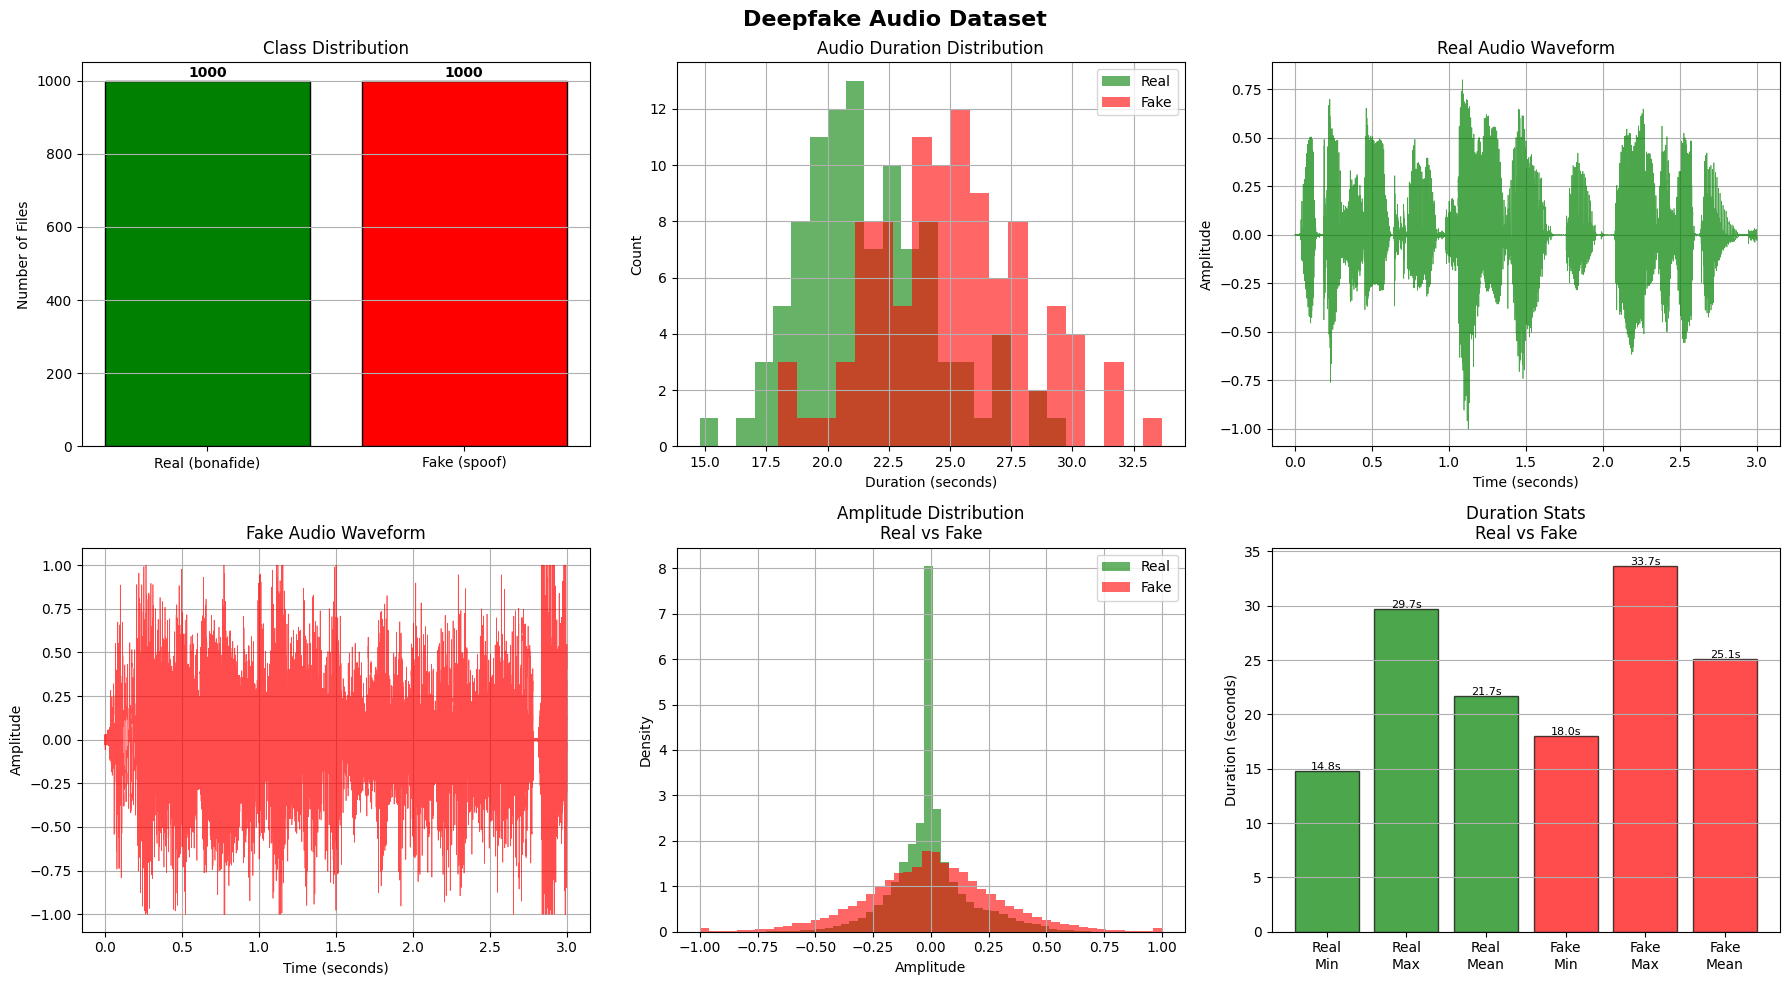


Summary:
Total files     : 2000
Real files      : 1000
Fake files      : 1000
Real duration   : 21.70s avg
Fake duration   : 25.12s avg


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import os
from pathlib import Path

def plot_eda(wavs_dir="/content/lens_data/dev/wavs"):

    wav_files = os.listdir(wavs_dir)
    real_files = [f for f in wav_files if "bonafide" in f]
    fake_files = [f for f in wav_files if "spoof" in f]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Deepfake Audio Dataset",
                 fontsize=16, fontweight="bold")

    # Graph 1 — Class Distribution
    axes[0,0].bar(
        ["Real (bonafide)", "Fake (spoof)"],
        [len(real_files), len(fake_files)],
        color=["green", "red"],
        edgecolor="black"
    )
    axes[0,0].set_title("Class Distribution")
    axes[0,0].set_ylabel("Number of Files")
    for i, v in enumerate([len(real_files), len(fake_files)]):
        axes[0,0].text(i, v + 10, str(v),
                       ha='center', fontweight='bold')
    axes[0,0].grid(True, axis='y')



    #Graph 2 Duration Distribution
    real_durations = []
    fake_durations = []

    # Sample 100 files each (faster)
    for f in real_files[:100]:
        info = sf.info(str(Path(wavs_dir) / f))
        real_durations.append(info.duration)

    for f in fake_files[:100]:
        info = sf.info(str(Path(wavs_dir) / f))
        fake_durations.append(info.duration)

    axes[0,1].hist(real_durations, bins=20,
                   alpha=0.6, color='green', label='Real')
    axes[0,1].hist(fake_durations, bins=20,
                   alpha=0.6, color='red',   label='Fake')
    axes[0,1].set_title("Audio Duration Distribution")
    axes[0,1].set_xlabel("Duration (seconds)")
    axes[0,1].set_ylabel("Count")
    axes[0,1].legend()
    axes[0,1].grid(True)

    #Graph 3 — Waveform Comparison
    real_audio, sr = sf.read(str(Path(wavs_dir) / real_files[0]))
    fake_audio, _  = sf.read(str(Path(wavs_dir) / fake_files[0]))

    # Take first 3 seconds only
    real_audio = real_audio[:sr*3]
    fake_audio = fake_audio[:sr*3]

    time_axis_real = np.linspace(0, 3, len(real_audio))
    time_axis_fake = np.linspace(0, 3, len(fake_audio))

    axes[0,2].plot(time_axis_real, real_audio,
                   color='green', alpha=0.7, linewidth=0.5)
    axes[0,2].set_title("Real Audio Waveform")
    axes[0,2].set_xlabel("Time (seconds)")
    axes[0,2].set_ylabel("Amplitude")
    axes[0,2].grid(True)

    #Graph 4 — Fake Waveform
    axes[1,0].plot(time_axis_fake, fake_audio,
                   color='red', alpha=0.7, linewidth=0.5)
    axes[1,0].set_title("Fake Audio Waveform")
    axes[1,0].set_xlabel("Time (seconds)")
    axes[1,0].set_ylabel("Amplitude")
    axes[1,0].grid(True)

    #Graph 5 — Amplitude Distribution
    axes[1,1].hist(real_audio, bins=50,
                   alpha=0.6, color='green',
                   label='Real', density=True)
    axes[1,1].hist(fake_audio, bins=50,
                   alpha=0.6, color='red',
                   label='Fake', density=True)
    axes[1,1].set_title("Amplitude Distribution\nReal vs Fake")
    axes[1,1].set_xlabel("Amplitude")
    axes[1,1].set_ylabel("Density")
    axes[1,1].legend()
    axes[1,1].grid(True)

    #  Graph 6 — Average Duration Stats
    stats = {
        'Real\nMin'  : min(real_durations),
        'Real\nMax'  : max(real_durations),
        'Real\nMean' : np.mean(real_durations),
        'Fake\nMin'  : min(fake_durations),
        'Fake\nMax'  : max(fake_durations),
        'Fake\nMean' : np.mean(fake_durations),
    }
    colors = ['green', 'green', 'green', 'red', 'red', 'red']

    axes[1,2].bar(stats.keys(), stats.values(),
                  color=colors, edgecolor='black', alpha=0.7)
    axes[1,2].set_title("Duration Stats\nReal vs Fake")
    axes[1,2].set_ylabel("Duration (seconds)")
    axes[1,2].grid(True, axis='y')
    for i, (k, v) in enumerate(stats.items()):
        axes[1,2].text(i, v + 0.1, f"{v:.1f}s",
                       ha='center', fontsize=8)

    plt.tight_layout()

    # Save locally
    plt.savefig("/content/eda_plots.png", dpi=150, bbox_inches='tight')
    print("EDA plots saved!")
    plt.show()

    # Print summary stats
    print("\nSummary:")
    print(f"Total files     : {len(wav_files)}")
    print(f"Real files      : {len(real_files)}")
    print(f"Fake files      : {len(fake_files)}")
    print(f"Real duration   : {np.mean(real_durations):.2f}s avg")
    print(f"Fake duration   : {np.mean(fake_durations):.2f}s avg")

# Run it!
plot_eda()

In [ ]:
#Splitting the data

def split_dataset(config):
  random.seed(42)

  wavs_dir = Path(config["Input_wave_path"])
  output_dir = Path(config["output_wave_path"])

  #get all the files and then segregate real and fake

  all_files = list(wavs_dir.glob("*.wav"))
  real_files = [f for f in all_files if  "bonafide" in f.name]
  fake_files = [f for f in all_files if  "spoof" in f.name]

  #Printing the count, since we already saw it 1000 before expecting the same
  print(f"Total files : {len(all_files)}")
  print(f"Real (bonafide): {len(real_files)}")
  print(f"Fake (spoof)   : {len(fake_files)}")

  def split(files):
    random.shuffle(files)

    n = len(files)
    n_train = int(0.7*n)
    n_val = int(0.15*n)

    train = files[:n_train]
    val = files[n_train:n_train+n_val]
    test = files[n_train+n_val:]

    return train, val, test

  real_train, real_val, real_test = split(real_files)
  print(f"Real train: {len(real_train)}")
  print(f"Real val: {len(real_val)}")
  print(f"Real test: {len(real_test)}")
  fake_train, fake_val, fake_test = split(fake_files)
  print("---------------------------")
  print(f"Fake train: {len(fake_train)}")
  print(f"Fake val: {len(fake_val)}")
  print(f"Fake test: {len(fake_test)}")

  splits = {
      "train" : (real_train, fake_train),
      "val" : (real_val, fake_val),
      "test" : (real_test, fake_test)
  }

  print("Creating directorires to store all the related to train/val/test in 3 different folders")
  for split_name, (real_list, fake_splits) in splits.items():
    for label, file_list in [("real", real_list), ("fake", fake_splits)]:
      output_split_dir = output_dir / split_name / label

      # We check if the folder exists AND if it has the correct number of files
      if output_split_dir.exists():
        existingfiles = list(output_split_dir.glob("*.wav"))
        if len(existingfiles) == len(file_list):
          print(f"Skipping {split_name}/{label}")
          continue

      output_split_dir.mkdir(parents=True, exist_ok=True)
      for file in file_list:
        shutil.copy(file, output_split_dir / file.name)



  print("Dataset is stored in the order ")
  print("Train -> Real -> Fake")
  print("Val   -> Real -> Fake")
  print("Test  -> Real -> Fake")

In [ ]:
split_path = "/content/lens_data/dev/output_wavs"
needs_splitting = True

if os.path.exists(split_path):
    # Check a "leaf" folder to see if it's populated
    test_fake_dir = os.path.join(split_path, "test/fake")
    if os.path.exists(test_fake_dir) and len(os.listdir(test_fake_dir)) > 0:
        print("Splits already exist. Skipping function call.")
        needs_splitting = False

if needs_splitting:
    print(" Running split_dataset...")
    split_dataset(config)
else:
    print("Done! Data is ready.")

 Running split_dataset...
Total files : 2000
Real (bonafide): 1000
Fake (spoof)   : 1000
Real train: 700
Real val: 150
Real test: 150
---------------------------
Fake train: 700
Fake val: 150
Fake test: 150
Creating directorires to store all the related to train/val/test in 3 different folders
Dataset is stored in the order 
Train -> Real -> Fake
Val   -> Real -> Fake
Test  -> Real -> Fake


In [ ]:

class AudioDataset(Dataset):
    def __init__(self, split, config):
        self.num_samples = config["number_of_sample"]
        self.sample_rate = config["sample_rate"]

        root = Path(config["output_wave_path"]) / split

        self.files  = []
        self.labels = []

        for label_name, label in [("real", 0), ("fake", 1)]:
            for f in (root / label_name).glob("*.wav"):
                self.files.append(f)
                self.labels.append(label)

        self.resamplers = {}
        print(f"{split:5s} → {len(self.files)} files loaded")

    def __len__(self):
        return len(self.files)

    def _load_audio(self, path):
        audio, sr = sf.read(str(path), always_2d=True)
        audio     = audio.mean(axis=1)      # stereo → mono
        waveform  = torch.tensor(audio, dtype=torch.float32)

        # resample if needed
        if sr != self.sample_rate:
            if sr not in self.resamplers:
                self.resamplers[sr] = T.Resample(sr, self.sample_rate)
            waveform = self.resamplers[sr](waveform)

        return waveform

    def __getitem__(self, idx):
        waveform = self._load_audio(self.files[idx])
        label    = self.labels[idx]

        # Fix length to exactly 5 seconds
        if waveform.shape[0] < self.num_samples:
            # Too short → pad with zeros (silence)
            pad      = self.num_samples - waveform.shape[0]
            waveform = torch.nn.functional.pad(waveform, (0, pad))
        else:
            # Too long → random crop
            start    = random.randint(0, waveform.shape[0] - self.num_samples)
            waveform = waveform[start:start + self.num_samples]

        # Normalize
        waveform = (waveform - waveform.mean()) / (waveform.std() + 1e-6)

        return waveform, torch.tensor(label, dtype=torch.float32)

# Create datasets
train_ds = AudioDataset("train", config)
val_ds   = AudioDataset("val",   config)
test_ds  = AudioDataset("test",  config)

# Verify one sample
x, y = train_ds[0]
print(f"\nOne sample:")
print(f"Shape  : {x.shape}")     # should be [80000]
print(f"Label  : {y}")           # 0.0 = real, 1.0 = fake
print(f"Min    : {x.min():.3f}")
print(f"Max    : {x.max():.3f}")
print(f"Mean   : {x.mean():.3f}") # should be close to 0

train → 1400 files loaded
val   → 300 files loaded
test  → 300 files loaded

One sample:
Shape  : torch.Size([160000])
Label  : 0.0
Min    : -3.652
Max    : 3.658
Mean   : -0.000


In [ ]:

train_loader = DataLoader(
    train_ds,
    batch_size  = config["batchsize"],
    shuffle     = True,               # shuffle for training
    num_workers = 0
)

val_loader = DataLoader(
    val_ds,
    batch_size  = config["batchsize"],
    shuffle     = False,              # no shuffle for validation
    num_workers = 0
)

test_loader = DataLoader(
    test_ds,
    batch_size  = config["batchsize"],
    shuffle     = False,              # no shuffle for testing
    num_workers = 0
)

# Verify one batch
x, y = next(iter(train_loader))
print(f" DataLoaders ready!")
print(f"Batch shape : {x.shape}")    # [8, x]
print(f"Labels      : {y}")          #  labels (0s and 1s)

 DataLoaders ready!
Batch shape : torch.Size([8, 160000])
Labels      : tensor([0., 0., 0., 1., 0., 0., 1., 0.])


In [ ]:

class Wav2Vec2Classifier(nn.Module):
    def __init__(self, config):
        super().__init__()

        # Load pretrained Wav2Vec2
        # This downloads ~360MB model from internet
        self.wav2vec    = Wav2Vec2Model.from_pretrained(config["model_name"])

        # Your classifier on top
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),    # 768 → 256
            nn.ReLU(),
            nn.Dropout(0.3),        # prevent overfitting
            nn.Linear(256, 1)       # 256 → single output
        )

    def freeze_wav2vec(self):
        # Phase 1 — freeze all wav2vec weights
        for param in self.wav2vec.parameters():
            param.requires_grad = False
        print(" Wav2Vec2 frozen — training classifier only")

    def unfreeze_wav2vec(self):
        # Phase 2 — unfreeze last 4 transformer layers
        for i, layer in enumerate(self.wav2vec.encoder.layers):
            if i >= 8:              # layers 8, 9, 10, 11
                for param in layer.parameters():
                    param.requires_grad = True
                print(f"Frozing this layer{i}")# layers unfrozen — finetuning!")


    def forward(self, x):
        # x shape entering  : [x, 80000]
        outputs = self.wav2vec(x)

        # hidden states     : [x, 249, 768]
        hidden  = outputs.last_hidden_state

        # mean pooling      : [x, 768]
        pooled  = hidden.mean(dim=1)

        # classifier output : [x, 1] → [x]
        return self.classifier(pooled).squeeze(1)

# Setup device and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

model  = Wav2Vec2Classifier(config).to(device)

# Count parameters
total  = sum(p.numel() for p in model.parameters())
print(f" Model created!")
print(f"Total parameters: {total:,}")

Using: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Model created!
Total parameters: 94,568,833


In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np


def run_epoch(model, loader, criterion, optimizer, device, train=True):
    model.train() if train else model.eval()

    total_loss      = 0.0
    all_preds       = []
    all_labels      = []

    for x, y in tqdm(loader, desc="Train" if train else "Val"):
        x, y = x.to(device), y.to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(x)
            loss   = criterion(logits, y)

            if train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)
        pred        = (torch.sigmoid(logits) > 0.3).float()

        all_preds.extend(pred.detach().cpu().numpy())
        all_labels.extend(y.detach().cpu().numpy())

    avg_loss  = total_loss / len(loader.dataset)
    acc       = accuracy_score(all_labels, all_preds)
    f1        = f1_score(all_labels, all_preds, zero_division=0)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall    = recall_score(all_labels, all_preds, zero_division=0)

    return avg_loss, acc, f1, precision, recall


def plot_confusion_matrix(model, loader, device, class_names=["Real", "Fake"]):
    """Run inference on loader and plot raw + normalised confusion matrices."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Confusion Matrix"):
            x = x.to(device)
            logits = model(x)
            pred   = (torch.sigmoid(logits) > 0.3).float()
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    cm      = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Raw counts
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=axes[0], colorbar=False, cmap="Blues"
    )
    axes[0].set_title("Confusion Matrix (Counts)", fontweight="bold")

    # Normalised
    ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
        ax=axes[1], colorbar=False, cmap="Blues"
    )
    axes[1].set_title("Confusion Matrix (Normalised)", fontweight="bold")

    plt.suptitle("Test Set — Confusion Matrix", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Early stopping class (unchanged)
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience    = patience
        self.counter     = 0
        self.best_f1     = 0.0
        self.should_stop = False

    def check(self, val_f1):
        if val_f1 > self.best_f1:
            self.best_f1 = val_f1
            self.counter = 0
            print(f"  Improved! Best F1: {self.best_f1:.4f}")
            return True
        else:
            self.counter += 1
            print(f"  No improvement for {self.counter}/{self.patience} epochs")
            if self.counter >= self.patience:
                self.should_stop = True
                print("  Early stopping triggered!")
            return False

In [ ]:
import matplotlib.pyplot as plt

criterion  = nn.BCEWithLogitsLoss()
early_stop = EarlyStopping(patience=3)

history = {
    "train_loss" : [],
    "val_loss"   : [],
    "train_acc"  : [],
    "val_acc"    : [],
    "train_f1"   : [],
    "val_f1"     : [],
    "train_prec" : [],
    "val_prec"   : [],
    "train_rec"  : [],
    "val_rec"    : [],
    "phase"      : []
}

# ── PHASE 1 ──────────────────────────────────────────
print("=" * 50)
print("PHASE 1 — Classifier head only")
print("=" * 50)

model.freeze_wav2vec()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config["learningrate_classifierhead"]
)

for epoch in range(config["freezeEpochs"]):
    print(f"\nEpoch {epoch+1}/{config['freezeEpochs']}")

    train_loss, train_acc, train_f1, train_prec, train_rec = run_epoch(
        model, train_loader, criterion, optimizer, device, train=True
    )
    val_loss, val_acc, val_f1, val_prec, val_rec = run_epoch(
        model, val_loader, criterion, optimizer, device, train=False
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)
    history["train_prec"].append(train_prec)
    history["val_prec"].append(val_prec)
    history["train_rec"].append(train_rec)
    history["val_rec"].append(val_rec)
    history["phase"].append(1)

    print(f"Train → loss:{train_loss:.4f}  acc:{train_acc:.4f}  f1:{train_f1:.4f}  prec:{train_prec:.4f}  rec:{train_rec:.4f}")
    print(f"Val   → loss:{val_loss:.4f}   acc:{val_acc:.4f}   f1:{val_f1:.4f}   prec:{val_prec:.4f}   rec:{val_rec:.4f}")

    if early_stop.check(val_f1):
        torch.save(model.state_dict(), config["savepath"])
        print("  Best model saved!")

    if early_stop.should_stop:
        print("  Early stopping Phase 1!")
        break

#Capture Phase 1 best before resetting
phase1_best_f1 = early_stop.best_f1
print(f"\nPhase 1 complete. Best Val F1: {phase1_best_f1:.4f}")

# ── PHASE 2 ──────────────────────────────────────────
early_stop          = EarlyStopping(patience=3)
early_stop.best_f1  = phase1_best_f1   # ✅ carry over so Phase 2 must beat Phase 1

print("\n" + "=" * 50)
print("PHASE 2 — Finetuning Wav2Vec2 layers")
print("=" * 50)

model.unfreeze_wav2vec()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config["learningrate_wav2vec"]
)

for epoch in range(config["epochs"] - config["freezeEpochs"]):
    print(f"\nEpoch {epoch+1}/{config['epochs'] - config['freezeEpochs']}")

    train_loss, train_acc, train_f1, train_prec, train_rec = run_epoch(
        model, train_loader, criterion, optimizer, device, train=True
    )
    val_loss, val_acc, val_f1, val_prec, val_rec = run_epoch(
        model, val_loader, criterion, optimizer, device, train=False
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)
    history["train_prec"].append(train_prec)
    history["val_prec"].append(val_prec)
    history["train_rec"].append(train_rec)
    history["val_rec"].append(val_rec)
    history["phase"].append(2)

    print(f"Train → loss:{train_loss:.4f}  acc:{train_acc:.4f}  f1:{train_f1:.4f}  prec:{train_prec:.4f}  rec:{train_rec:.4f}")
    print(f"Val   → loss:{val_loss:.4f}   acc:{val_acc:.4f}   f1:{val_f1:.4f}   prec:{val_prec:.4f}   rec:{val_rec:.4f}")

    if early_stop.check(val_f1):
        torch.save(model.state_dict(), config["savepath"])
        print("  Best model saved!")

    if early_stop.should_stop:
        print("  Early stopping Phase 2!")
        break

print(f"\nTraining done! Best Val F1: {early_stop.best_f1:.4f}")

PHASE 1 — Classifier head only
 Wav2Vec2 frozen — training classifier only

Epoch 1/3


Val: 100%|██████████| 38/38 [00:16<00:00,  2.33it/s]


Train → loss:0.6879  acc:0.5000  f1:0.6667  prec:0.5000  rec:1.0000
Val   → loss:0.6609   acc:0.5000   f1:0.6667   prec:0.5000   rec:1.0000
  Improved! Best F1: 0.6667
  Best model saved!

Epoch 2/3


Val: 100%|██████████| 38/38 [00:15<00:00,  2.49it/s]


Train → loss:0.6684  acc:0.5036  f1:0.6657  prec:0.5018  rec:0.9886
Val   → loss:0.6739   acc:0.5933   f1:0.6919   prec:0.5569   rec:0.9133
  Improved! Best F1: 0.6919
  Best model saved!

Epoch 3/3


...

Train → loss:0.3520  acc:0.8157  f1:0.8294  prec:0.7722  rec:0.8957
Val   → loss:0.3640   acc:0.8700   f1:0.8612   prec:0.9237   rec:0.8067
  Improved! Best F1: 0.8612
  Best model saved!

Epoch 6/7


Val: 100%|██████████| 38/38 [00:15<00:00,  2.49it/s]


Train → loss:0.3165  acc:0.8414  f1:0.8492  prec:0.8096  rec:0.8929
Val   → loss:0.5294   acc:0.8100   f1:0.7729   prec:0.9604   rec:0.6467
  No improvement for 1/3 epochs

Epoch 7/7


Val: 100%|██████████| 38/38 [00:15<00:00,  2.49it/s]

Train → loss:0.2991  acc:0.8671  f1:0.8745  prec:0.8286  rec:0.9257
Val   → loss:0.3805   acc:0.8600   f1:0.8478   prec:0.9286   rec:0.7800
  No improvement for 2/3 epochs

Training done! Best Val F1: 0.8612


 Plot saved to Local !


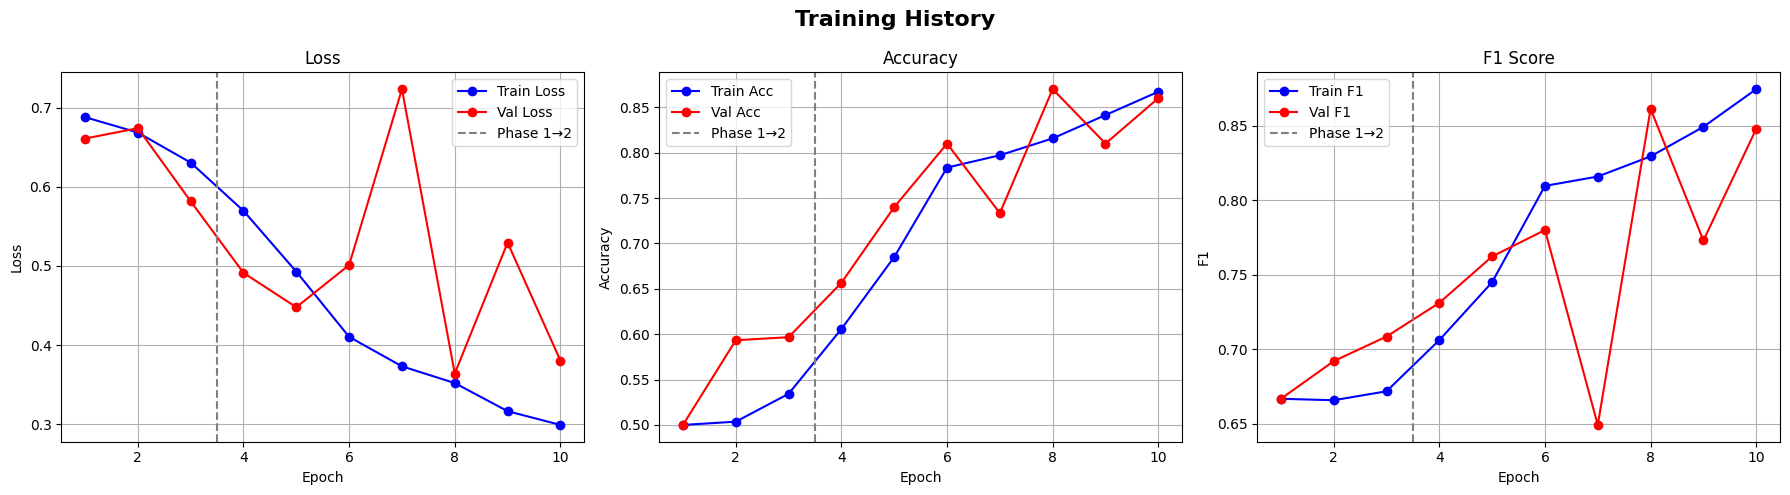

In [ ]:

def plot_history(history):
    epochs     = range(1, len(history["train_loss"]) + 1)
    phase1_end = history["phase"].count(1)  # where phase 1 ends

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Training History", fontsize=16, fontweight="bold")

    #Loss
    axes[0].plot(epochs, history["train_loss"], 'b-o', label="Train Loss")
    axes[0].plot(epochs, history["val_loss"],   'r-o', label="Val Loss")
    axes[0].axvline(x=phase1_end + 0.5, color='gray', linestyle='--', label="Phase 1→2")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], 'b-o', label="Train Acc")
    axes[1].plot(epochs, history["val_acc"],   'r-o', label="Val Acc")
    axes[1].axvline(x=phase1_end + 0.5, color='gray', linestyle='--', label="Phase 1→2")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    #F1 Score
    axes[2].plot(epochs, history["train_f1"], 'b-o', label="Train F1")
    axes[2].plot(epochs, history["val_f1"],   'r-o', label="Val F1")
    axes[2].axvline(x=phase1_end + 0.5, color='gray', linestyle='--', label="Phase 1→2")
    axes[2].set_title("F1 Score")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("F1")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()

    # Save to local content
    plot_path = "/content/training_history.png"
    plt.savefig(plot_path)
    print(f" Plot saved to Local !")
    plt.show()

plot_history(history)

In [ ]:
#Final evaluation on the test dataset

# Load best saved model
model.load_state_dict(torch.load(config["savepath"], map_location=device))
print("Best model loaded!")

# Run on test set
test_loss, test_acc, test_f1, test_prec, test_rec = run_epoch(
    model, test_loader, criterion, optimizer, device, train=False
)


Best model loaded!


Val: 100%|██████████| 38/38 [00:16<00:00,  2.37it/s]


In [ ]:

print("FINAL TEST RESULTS")

print(f"Loss     : {test_loss:.4f}")
print(f"Accuracy : {test_acc:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall   : {test_rec:.4f}")

FINAL TEST RESULTS
Loss     : 0.4130
Accuracy : 0.8700
F1 Score : 0.8592
Precision: 0.9370
Recall   : 0.7933


Confusion Matrix: 100%|██████████| 38/38 [00:15<00:00,  2.50it/s]


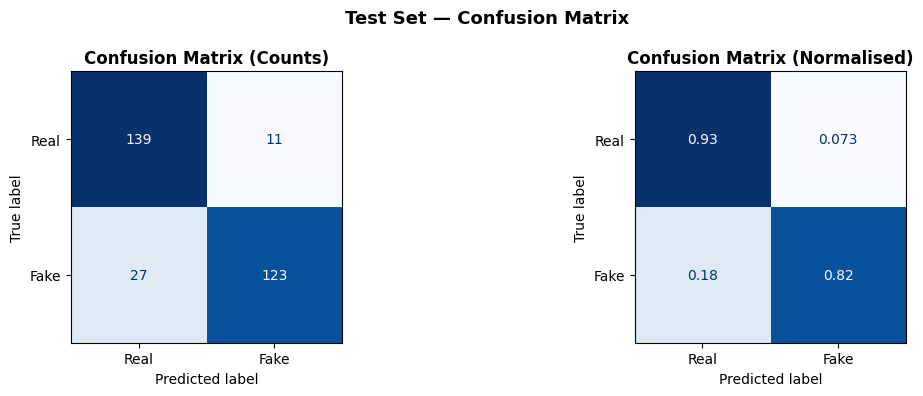

In [ ]:
#Call the confusion matrix
plot_confusion_matrix(model, test_loader, device)